In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gluonts.dataset.pandas import PandasDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from gluonts.torch.distributions import StudentTOutput
from lightning.pytorch.callbacks import EarlyStopping
import holidays
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [67]:
# ==========================================
# 2. Load Data
# ==========================================
df = pd.read_csv("df.csv")
df.head()

,date,store,item,sales
0,01-01-2013,1,1,13
1,02-01-2013,1,1,11
2,03-01-2013,1,1,14
3,04-01-2013,1,1,13
4,05-01-2013,1,1,10


In [68]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [69]:
# ==========================================
# 3. Feature Engineering
# ==========================================
india_holidays = holidays.India()

df['is_holiday'] = df['date'].apply(lambda x: int(x in india_holidays))
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# create unique id
df['item_id'] = df['store'].astype(str) + "_" + df['item'].astype(str)

In [ ]:
f = pd.DataFrame({
    'date': pd.date_range(start='2023-01-01', periods=10, freq='D'),
    'sales': np.random.randint(100, 500, size=10)
})

# Apply Fourier transformation
# periods: seasonal period (e.g., 7 for weekly seasonality)
# K: number of Fourier terms to generate
df_fourier = augment_fourier(
    data=df,
    date_column='date',
    periods=7,
    K=3
)

print(df_fourier)

In [70]:
# ==========================================
# 4. Train / Validation / Test Split
# ==========================================
test_size = 90
val_size = 270   # you can change this (e.g. 30, 60, 90)

train_dfs = []
val_dfs = []
test_dfs = []

for uid, group in df.groupby('item_id'):

    group = group.sort_values('date')

    # last 90 days → test
    test = group.iloc[-test_size:]

    # previous 90 days → validation
    val = group.iloc[-(test_size + val_size):-test_size]

    # rest → train
    train = group.iloc[:-(test_size + val_size)]

    train_dfs.append(train)
    val_dfs.append(val)
    test_dfs.append(test)

train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

In [71]:
# ==========================================
# 5. Convert to GluonTS Dataset
# ==========================================
train_ds = PandasDataset.from_long_dataframe(
    train_df,
    item_id="item_id",
    timestamp="date",
    target="sales",
    freq="D",
    feat_dynamic_real=["is_holiday", "dow", "month"]
)

test_ds = PandasDataset.from_long_dataframe(
    df,
    item_id="item_id",
    timestamp="date",
    target="sales",
    freq="D",
    feat_dynamic_real=["is_holiday", "dow", "month"]
)
val_ds = PandasDataset.from_long_dataframe(val_df,
item_id="item_id",
timestamp='date',
target='sales',
freq='D',
feat_dynamic_real=['is_holiday','dow','month'])

In [72]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [73]:
# ==========================================
# 6. Model
# ==========================================


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

estimator = DeepAREstimator(
    freq="D",
    prediction_length=90,
    context_length=750,
    num_layers=3,
    hidden_size=32,
    dropout_rate=0.1,

    lr=1e-3,

    trainer_kwargs={
        "max_epochs": 50,
        "gradient_clip_val": 0.1,
        "limit_val_batches": 1.0,
        "callbacks": [early_stop]
    }
)

predictor = estimator.train(train_ds, validation_data=val_ds)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: `Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
INFO:lightning.pytorch.utilities.rank_zero:`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: Epoch 28, global step 1450: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 28, global step 1450: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 29, global step 1500: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 29, global step 1500: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 30, global step 1550: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 30, global step 1550: 'val_loss' was not in top 1


In [74]:
# ==========================================
# 7. Test Forecast
# ==========================================
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100
)

forecasts = list(forecast_it)
tss = list(ts_it)

In [75]:
# ==========================================
# 8. Metrics
# ==========================================
rmse_list, mae_list, mape_list, r2_list = [], [], [], []

for ts, forecast in zip(tss, forecasts):

    y_true = ts[-90:].values
    y_pred = forecast.mean

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)
    mape_list.append(mape)
    r2_list.append(r2)

print("RMSE:", np.mean(rmse_list))
print("MAE:", np.mean(mae_list))
print("MAPE:", np.mean(mape_list))
print("R2:", np.mean(r2_list))

RMSE: 7.909683273576152
MAE: 6.298204174041748
MAPE: 25.968166467165734
R2: 0.5547046265006066


In [76]:
# ==========================================
# 9. Future Prediction (Next 90 Days)
# ==========================================
future_dfs = []

for uid, group in df.groupby('item_id'):

    last_date = group['date'].max()

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=90
    )

    future_df = pd.DataFrame({
        'date': future_dates,
        'item_id': uid
    })

    future_df['is_holiday'] = future_df['date'].apply(lambda x: int(x in india_holidays))
    future_df['dow'] = future_df['date'].dt.dayofweek
    future_df['month'] = future_df['date'].dt.month
    future_df['sales'] = 0  # placeholder

    future_dfs.append(future_df)

future_df = pd.concat(future_dfs)

full_future_df = pd.concat([df, future_df])

future_ds = PandasDataset.from_long_dataframe(
    full_future_df,
    item_id="item_id",
    timestamp="date",
    target="sales",
    freq="D",
    feat_dynamic_real=["is_holiday", "dow", "month"]
)

forecast_it_future, ts_it_future = make_evaluation_predictions(
    dataset=future_ds,
    predictor=predictor,
    num_samples=100
)

future_forecasts = list(forecast_it_future)
future_tss = list(ts_it_future)



<Figure size 1400x600 with 0 Axes>

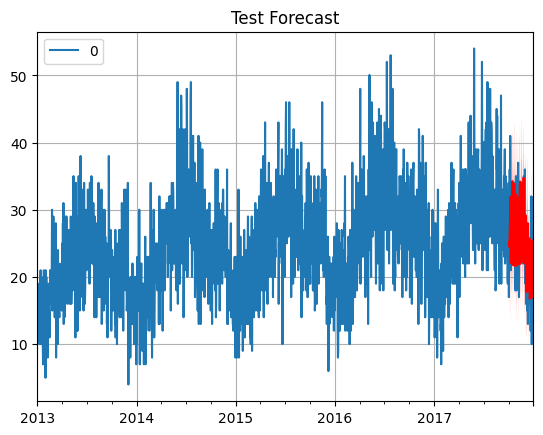

<Figure size 1400x600 with 0 Axes>

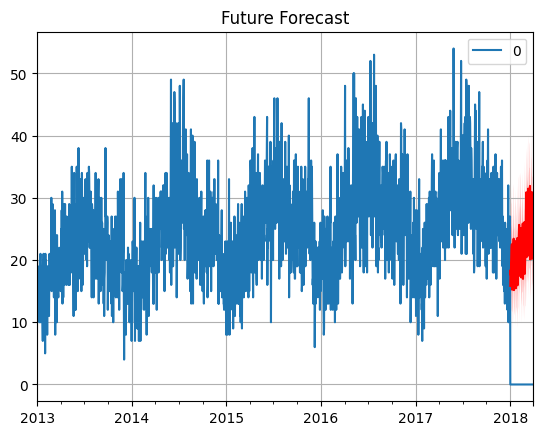

In [77]:
# ==========================================
# 10. Plot (Modeltime-style)
# ==========================================
def plot_forecast(ts, forecast, title="Forecast"):

    plt.figure(figsize=(14,6))

    # Train + Test
    ts.plot(label="Actual")

    # Forecast
    forecast.plot(color='red')

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# plot first series
plot_forecast(tss[0], forecasts[0], "Test Forecast")

# future plot
plot_forecast(future_tss[0], future_forecasts[0], "Future Forecast")